Processing 1981-1990...
1985
Processing 1991-2000...
1995
Processing 2001-2010...
2005
Processing 2011-2020...
2015
Processing 2015-2024...
2025
Saved to record_breaking_probability_raw.nc


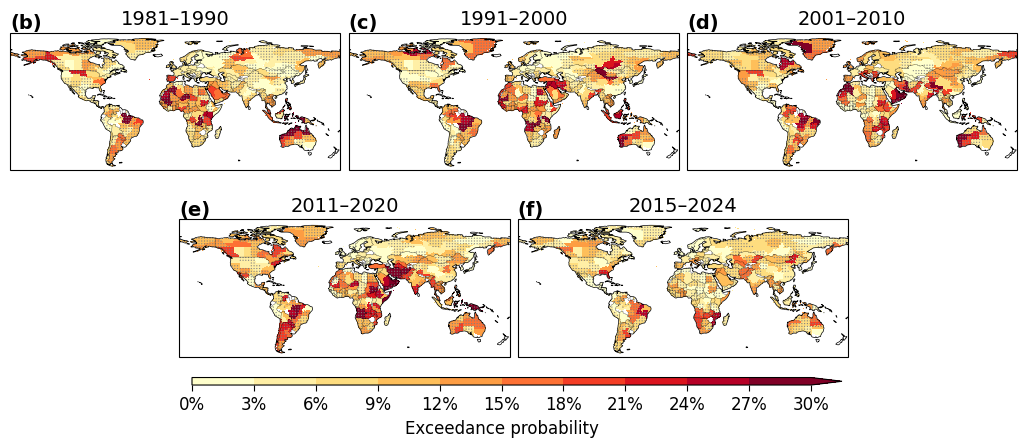

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from scipy.stats import genextreme as gev
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.ticker import FuncFormatter
from matplotlib.colors import BoundaryNorm
from matplotlib.gridspec import GridSpec

# =========================================================
# === Load data
# =========================================================
ecmwf_ds = xr.open_dataset("/home/users/kastanie/Global_regional_analysis/atmos-WRAF01-v4-1/hottestmonth/IFS_t2m_hottest_month.nc")
rl_ds = xr.open_dataset("/home/users/kastanie/Global_regional_analysis/atmos-WRAF01-v4-1/hottestmonth/observation_up_to_2025.nc")
mask_ds = xr.open_dataset(
    "/home/users/kastanie/Global_regional_analysis/atmos-WRAF01-v4-1/region_mask_1deg.nc"
)

fidelity_ds = xr.open_dataset(
    "/home/users/kastanie/Global_regional_analysis/atmos-WRAF01-v4-1/hottestmonth/grid_comparison_fidelity_trend_corrected.nc"
)

region_ids = mask_ds['region_id'].values
lat = mask_ds['latitude'].values
lon = mask_ds['longitude'].values

fidelity = fidelity_ds["fidelity_score"]
fidelity_mask = fidelity == 3
hatch_mask = (~fidelity_mask.values) & (~np.isnan(region_ids))

t2m_ifs_all = ecmwf_ds['t2m_hottest_month']
t2m_berkeley_all = rl_ds['t2m_hottest']

n_regions = 237

# =========================================================
# === Time periods
# =========================================================
time_periods = [
    (1981, 1990),
    (1991, 2000),
    (2001, 2010),
    (2011, 2020),
    (2015, 2024)
]

# =========================================================
# === 🔥 Record reference definition (FIXED LOGIC)
# =========================================================
record_end_year = {
    (1981, 1990): 1985,
    (1991, 2000): 1995,
    (2001, 2010): 2005,
    (2011, 2020): 2015,
    (2015, 2024): 2025
}

# =========================================================
# === Helper: max record function
# =========================================================
def get_max_before_year(ds, start, end):
    sub = ds.sel(year=(ds.year >= start) & (ds.year <= end))
    return sub['t2m_hottest'].max(dim='year')

# =========================================================
# === Probability matrix
# =========================================================
n_periods = len(time_periods)
prob_map = np.full((n_regions, n_periods), np.nan)

# =========================================================
# === Main loop
# =========================================================
for i, (start, end) in enumerate(time_periods):
    print(f"Processing {start}-{end}...")

    # ---- model + obs alignment ----
    period_mask_ifs = (ecmwf_ds.year >= start) & (ecmwf_ds.year <= end)
    period_mask_berkeley = (rl_ds.year >= start) & (rl_ds.year <= end)

    t2m_ifs_period = t2m_ifs_all.sel(year=period_mask_ifs)
    t2m_berkeley_period = t2m_berkeley_all.sel(year=period_mask_berkeley)

    ifs_mean = t2m_ifs_period.mean(dim='year')
    berkeley_mean = t2m_berkeley_period.mean(dim='year')

    t2m_corrected = t2m_ifs_period - ifs_mean + berkeley_mean

    # =====================================================
    # 🔥 KEY FIX: period-dependent record value
    # =====================================================
    record_end = record_end_year[(start, end)]
    print(record_end)
    max_t2m = get_max_before_year(rl_ds, 1940, record_end)
    # max_t2m = get_max_before_year(rl_ds, 1940, end+1)
    # reshape for GEV
    values = t2m_corrected.values.transpose(0, 2, 1).reshape(-1, n_regions)

    # =====================================================
    # GEV fit per region
    # =====================================================
    for r in range(n_regions):
        series = values[:, r]
        series = series[~np.isnan(series)]

        if len(series) < 30:
            continue

        try:
            c, loc, scale = gev.fit(series)

            x = max_t2m.sel(region_id=r).item()
            F = gev.cdf(x, c, loc=loc, scale=scale)

            prob_map[r, i] = 1 - F

        except Exception:
            continue

# =========================================================
# === Save NetCDF
# =========================================================
period_labels = [f"{s}-{e}" for s, e in time_periods]

prob_ds_out = xr.Dataset(
    {
        "record_breaking_probability": (("region_id", "period"), prob_map)
    },
    coords={
        "region_id": np.arange(n_regions),
        "period": period_labels
    }
)

prob_ds_out.to_netcdf("record_breaking_probability_raw.nc")
print("Saved to record_breaking_probability_raw.nc")

# =========================================================
# === Plot settings
# =========================================================
bounds = np.arange(0, 0.301, 0.03)
cmap = plt.get_cmap("YlOrRd", len(bounds) - 1)
norm = BoundaryNorm(boundaries=bounds, ncolors=cmap.N)

def plot_prob_map(region_data, title, ax, dot_size=0.8, dot_color='grey'):

    map_data = np.full_like(region_ids, np.nan, dtype=np.float64)

    for r in range(n_regions):
        map_data[region_ids == r] = region_data[r]

    masked_data = np.ma.masked_invalid(map_data)

    im = ax.pcolormesh(
        lon, lat, masked_data,
        transform=ccrs.PlateCarree(),
        cmap=cmap,
        norm=norm
    )

    # low fidelity hatch dots
    low_fid_mask = hatch_mask
    lons_dot, lats_dot = np.meshgrid(lon, lat)

    rows, cols = np.where(low_fid_mask)

    row_step = 3
    col_step = 3

    mask_sparse = (rows % row_step == 0) & (cols % col_step == 0)

    rows_sparse = rows[mask_sparse]
    cols_sparse = cols[mask_sparse]

    lons_dot = lons_dot[rows_sparse, cols_sparse]
    lats_dot = lats_dot[rows_sparse, cols_sparse]

    ax.scatter(
        lons_dot, lats_dot,
        s=dot_size,
        c=dot_color,
        marker='o',
        edgecolors='none',
        transform=ccrs.PlateCarree(),
        alpha=1
    )

    ax.set_extent([-180, 180, -60, 90], crs=ccrs.PlateCarree())
    ax.coastlines(linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.2)
    ax.set_title(title, fontsize=14)

    return im

# =========================================================
# === Figure
# =========================================================
def plot_gev_probability_grid(prob_map):

    fig = plt.figure(figsize=(13, 5))
    gs = GridSpec(2, 6, figure=fig, height_ratios=[1, 0.9])

    axes = [
        fig.add_subplot(gs[0, 0:2], projection=ccrs.PlateCarree()),
        fig.add_subplot(gs[0, 2:4], projection=ccrs.PlateCarree()),
        fig.add_subplot(gs[0, 4:6], projection=ccrs.PlateCarree()),
        fig.add_subplot(gs[1, 1:3], projection=ccrs.PlateCarree()),
        fig.add_subplot(gs[1, 3:5], projection=ccrs.PlateCarree())
    ]

    labels = ['(b)', '(c)', '(d)', '(e)', '(f)']

    for i, ax in enumerate(axes):
        start, end = time_periods[i]
        title = f"{start}–{end}"

        im = plot_prob_map(prob_map[:, i], title, ax)

        ax.text(
            0.00, 1.03,
            labels[i],
            transform=ax.transAxes,
            fontsize=14,
            fontweight='bold'
        )

    fig.subplots_adjust(wspace=0.05, hspace=0.02, top=0.92, bottom=0.18)

    cbar_ax = fig.add_axes([0.265, 0.16, 0.5, 0.015])

    cbar = fig.colorbar(
        plt.cm.ScalarMappable(norm=norm, cmap=cmap),
        cax=cbar_ax,
        orientation='horizontal',
        ticks=bounds,
        extend='max'
    )

    formatter = FuncFormatter(lambda x, _: f"{x*100:.0f}%")
    cbar.ax.set_xticklabels([formatter(t) for t in bounds])
    cbar.ax.tick_params(labelsize=12, length=4)
    cbar.set_label("Exceedance probability", fontsize=12)

    plt.savefig(
        "Fig2_record_breaking_probability_all_periods.pdf",
        dpi=800,
        bbox_inches='tight'
    )

    plt.show()

# =========================================================
# === Run
# =========================================================
plot_gev_probability_grid(prob_map)

In [2]:

import xarray as xr

ds = xr.open_dataset("record_breaking_probability_raw.nc")

print(ds)

<xarray.Dataset> Size: 12kB
Dimensions:                      (region_id: 237, period: 5)
Coordinates:
  * region_id                    (region_id) int64 2kB 0 1 2 3 ... 234 235 236
  * period                       (period) <U9 180B '1981-1990' ... '2015-2024'
Data variables:
    record_breaking_probability  (region_id, period) float64 9kB ...


In [3]:
import xarray as xr

# =========================================================
# 1. Read dataset
# =========================================================
ds = xr.open_dataset("record_breaking_probability_raw.nc")

# =========================================================
# 2. Extract variable
# =========================================================
prob = ds["record_breaking_probability"]

# =========================================================
# 3. Find regions where probability > 50% for each period
# =========================================================
threshold = 1/6

for p in ds.period.values:
    
    # Select one period
    prob_p = prob.sel(period=p)
    
    # Get region_ids where probability > 0.5
    region_ids = ds.region_id.where(prob_p > threshold, drop=True).values
    
    print(f"\nPeriod: {p}")
    print(f"Number of regions with probability > 50%: {len(region_ids)}")
    print(region_ids)


Period: 1981-1990
Number of regions with probability > 50%: 38
[  0.  18.  20.  30.  34.  35.  37.  45.  53.  54.  56.  63.  67.  68.
  70.  75.  78.  81.  82.  89.  90.  94.  95. 109. 158. 159. 160. 165.
 166. 167. 186. 188. 190. 202. 214. 215. 217. 228.]

Period: 1991-2000
Number of regions with probability > 50%: 39
[  3.   4.  14.  32.  34.  35.  36.  39.  40.  52.  54.  61.  63.  65.
  66.  73.  81.  84.  90.  91.  92.  94. 115. 116. 128. 131. 132. 146.
 159. 160. 161. 166. 192. 209. 214. 215. 216. 227. 229.]

Period: 2001-2010
Number of regions with probability > 50%: 47
[ 14.  20.  34.  35.  37.  38.  39.  40.  45.  51.  52.  53.  56.  63.
  68.  69.  70.  71.  75.  89.  93.  94.  95.  97. 124. 131. 132. 133.
 140. 143. 150. 151. 153. 159. 160. 161. 166. 167. 185. 192. 204. 205.
 209. 217. 218. 220. 226.]

Period: 2011-2020
Number of regions with probability > 50%: 51
[  7.   8.  14.  29.  35.  36.  39.  40.  41.  44.  45.  46.  49.  51.
  54.  62.  63.  68.  69.  70.  71.  72.

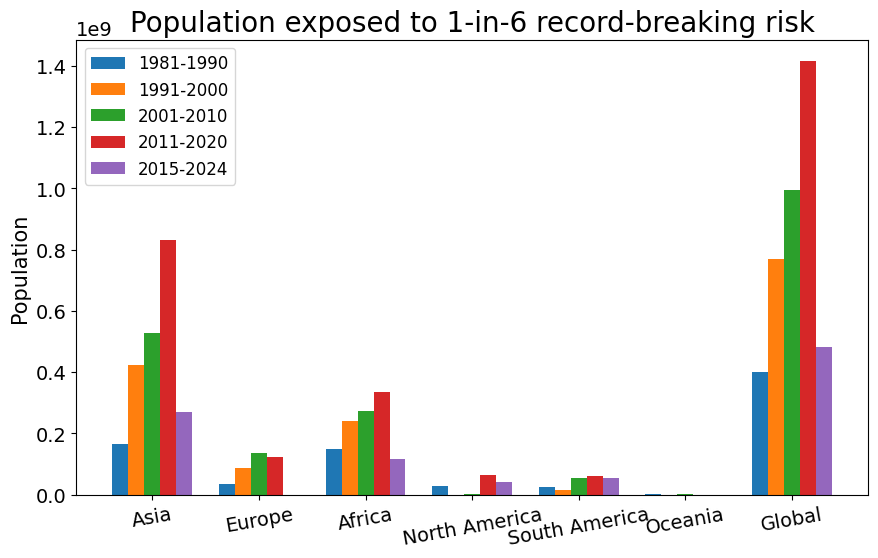

In [2]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# 1. Load data
# =========================================================
prob_ds = xr.open_dataset("record_breaking_probability_raw.nc")
pop_ds = xr.open_dataset("regional_population.nc")

prob = prob_ds["record_breaking_probability"]
pop = pop_ds["population"]

# =========================================================
# 2. Define continents
# =========================================================
continents = {
    "Asia": [70,108,109,110,111,112,113,114,115,116,117,118,119,120,121,
             122,123,124,125,126,127,130,133,135,136,137,138,139,140,141,
             142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,
             157,206,207,208,209,210,211,212,213,214,215,216,217,229,230,
             231,235,236],

    "Europe": [102,103,104,105,106,107,128,129,131,134,197,198,199,
               200,201,202,203,204,205,234],

    "Africa": [52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,
               69,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,
               87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,132,
               225,226,227,228],

    "North America": list(range(0,32)) + [218,219,220,221,222,223,224,232],

    "South America": list(range(32,52)) + [191,192,193,194,195,196,233],

    "Oceania": [158,159,160,161,162,163,164,165,166,167,168,169]
}

# =========================================================
# 3. Period → population year mapping
# =========================================================
period_to_year = {
    "1981-1990": 1985,
    "1991-2000": 1995,
    "2001-2010": 2005,
    "2011-2020": 2015,
    "2015-2024": 2025
}

periods = list(prob.period.values)

continent_names = list(continents.keys()) + ["Global"]

# result container
result = np.zeros((len(continent_names), len(periods)))

threshold = 1/6

# =========================================================
# 4. Compute population exposure
# =========================================================
for j, period in enumerate(periods):

    prob_p = prob.sel(period=period)

    # high-risk regions
    high_risk_regions = prob_p["region_id"].where(prob_p > threshold, drop=True).values

    year = period_to_year[period]
    pop_y = pop.sel(year=year)

    # -------------------------
    # continent-wise
    # -------------------------
    for i, cont in enumerate(list(continents.keys())):

        region_list = np.array(continents[cont])

        selected = np.intersect1d(region_list, high_risk_regions)

        if len(selected) == 0:
            total_pop = 0.0
        else:
            total_pop = pop_y.sel(region_id=selected).sum().values

        result[i, j] = total_pop

    # -------------------------
    # GLOBAL (new)
    # -------------------------
    if len(high_risk_regions) == 0:
        global_pop = 0.0
    else:
        global_pop = pop_y.sel(region_id=high_risk_regions).sum().values

    result[-1, j] = global_pop

# =========================================================
# 5. Plot grouped bar chart
# =========================================================
x = np.arange(len(continent_names))
width = 0.15
plt.rcParams.update({
    "font.size": 14,          # 全局基础字体
    "axes.titlesize": 20,     # 标题
    "axes.labelsize": 15,     # x/y轴标签
    "xtick.labelsize": 14,    # x刻度
    "ytick.labelsize": 14,    # y刻度
    "legend.fontsize": 12
})
fig, ax = plt.subplots(figsize=(9, 6))

for j, period in enumerate(periods):
    ax.bar(x + j * width, result[:, j], width, label=period)

ax.set_xticks(x + width * 2)
ax.set_xticklabels(continent_names, rotation=10)

ax.set_ylabel("Population")
ax.set_title("Population exposed to 1-in-6 record-breaking risk")
ax.legend()

plt.tight_layout()
plt.savefig("FigS7_population_exposure_by_continent_with_global.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [3]:
# =========================================================
# 6. Output global population exposure (in millions)
# =========================================================
global_values = result[-1, :] / 1e6  # convert to million

print("\nGlobal population exposure (million people):")
for period, val in zip(periods, global_values):
    print(f"{period}: {val:.2f} million")


Global population exposure (million people):
1981-1990: 401.77 million
1991-2000: 769.57 million
2001-2010: 994.67 million
2011-2020: 1414.94 million
2015-2024: 481.46 million


In [7]:
import xarray as xr
import numpy as np

# =========================================================
# 1. Load data
# =========================================================
prob_ds = xr.open_dataset("record_breaking_probability_up_2025.nc")
pop_ds = xr.open_dataset("regional_population.nc")

prob = prob_ds["record_breaking_probability"]
pop = pop_ds["population"]

# =========================================================
# 2. parameters
# =========================================================
threshold = 1/6
last_period = prob.period.values[-1]   # "2020-2024"
pop_year = 2025

# =========================================================
# 3. select data
# =========================================================
prob_last = prob.sel(period=last_period)
pop_last = pop.sel(year=pop_year)

# =========================================================
# 4. apply threshold mask
# =========================================================
mask = prob_last > threshold

# =========================================================
# 5. compute exposure (only above threshold)
# =========================================================
exposure = xr.where(mask, prob_last * pop_last, 0)

# =========================================================
# 6. total exposure
# =========================================================
total_exposure = exposure.sum().values

print("Threshold-weighted exposed population:", total_exposure)

Threshold-weighted exposed population: 182675116.76450953


In [8]:
import xarray as xr
import numpy as np

# =========================================================
# 1. Load data
# =========================================================
prob_ds = xr.open_dataset("record_breaking_probability_up_2025.nc")
pop_ds = xr.open_dataset("regional_population.nc")

prob = prob_ds["record_breaking_probability"]
pop = pop_ds["population"]

# =========================================================
# 2. parameters
# =========================================================
threshold = 1/6
last_period = prob.period.values[-1]   # "2020-2024"
pop_year = 2025

# =========================================================
# 3. select data
# =========================================================
prob_last = prob.sel(period=last_period)
pop_last = pop.sel(year=pop_year)

# =========================================================
# 4. mask (P > threshold)
# =========================================================
mask = prob_last > threshold

# =========================================================
# =========================================================
# 5. (1) HARD exposure: total population above threshold
# =========================================================
hard_exposure = pop_last.where(mask, 0).sum().values

# =========================================================
# 6. (2) EXPECTED exposure: P × population
# =========================================================
expected_exposure = (prob_last * pop_last).sum().values

# =========================================================
# 7. print results
# =========================================================
print("Hard exposed population (P > 1/6):", hard_exposure)
print("Expected exposed population (P × pop):", expected_exposure)

Hard exposed population (P > 1/6): 863630049.4364705
Expected exposed population (P × pop): 552208999.2170734


In [3]:
import xarray as xr
import numpy as np

# =========================================================
# 1. Load data
# =========================================================
# prob_ds = xr.open_dataset("record_breaking_probability_up_2025.nc")
prob_ds = xr.open_dataset("record_breaking_probability_raw.nc")
pop_ds = xr.open_dataset("regional_population.nc")

prob = prob_ds["record_breaking_probability"]
pop = pop_ds["population"]

# =========================================================
# 2. parameters
# =========================================================
threshold = 1/6
last_period = prob.period.values[0]   # "1981-1990"
pop_year = 1985

# =========================================================
# 3. select data
# =========================================================
prob_last = prob.sel(period=last_period)
pop_last = pop.sel(year=pop_year)

# =========================================================
# 4. mask (P > threshold)
# =========================================================
mask = prob_last > threshold

# =========================================================
# =========================================================
# 5. (1) HARD exposure: total population above threshold
# =========================================================
hard_exposure = pop_last.where(mask, 0).sum().values

# =========================================================
# 6. (2) EXPECTED exposure: P × population
# =========================================================
expected_exposure = (prob_last * pop_last).sum().values

# =========================================================
# 7. print results
# =========================================================
print("Hard exposed population (P > 1/6):", hard_exposure)
print("Expected exposed population (P × pop):", expected_exposure)

Hard exposed population (P > 1/6): 645120900.5234525
Expected exposed population (P × pop): 353266957.5934608
